# 解答例：Gray--Scottモデルの課題

元Notebook：[21_reaction_diffusion_gray_scott.ipynb](../21_reaction_diffusion_gray_scott.ipynb)．

課題と解答例，実行に必要な定義だけをまとめたNotebookである．上から実行できる．ここにある少数条件の結果は実装例であり，実画像への適合結果ではない．

## 課題：実装と検証

1. `scan_gray_scott(params, seed)` を作り，各 `(F, k)` の最終画像と `mean(v >= 0.2)` を保存する．領域長，格子，終了時刻，時間刻み，初期分布は共通にする．
2. `plot_gray_scott_scan(results)` を作り，共通の色範囲とカラーバーで画像を比較する．タイトルに `F`, `k`, 面積比を入れ，1条件だけでも動くようにする．
3. `diffusion_ratio_sweep(Dv_values)` を作り，濃度の平均・分散・面積比を表にする．分散は不均一さであり，波長ではないことを説明する．細かさは22章の波長関数を検証してから追加する．
4. `time_convergence(dts)` を作り，一様な初期値 `u=0.7, v=0` の厳密解と同じ終了時刻で比較する．最大誤差と誤差比を表示する．
5. 面積比と分散が近くても異なる模様を区別できるか，図と数値を対応させて考察する．複数seedや保存時刻でも結論が変わるかを確かめる．

## 実行に必要な共通定義

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def laplacian(Z, dx):
    return (np.roll(Z, 1, 0) + np.roll(Z, -1, 0)
            + np.roll(Z, 1, 1) + np.roll(Z, -1, 1) - 4*Z) / dx**2

def initial_fields(N, length, seed=0, amplitude=1.0):
    # 同じ連続的な周期関数を各格子で標本化する．濃度は非負．
    if not 0 <= amplitude <= 1:
        raise ValueError('amplitude must be between 0 and 1')
    x = np.arange(N) * length / N
    X, Y = np.meshgrid(x, x)
    distance = (np.sin(np.pi*(X-length/2)/length)**2
                + np.sin(np.pi*(Y-length/2)/length)**2) / (0.12*np.pi)**2
    patch = np.exp(-distance**3)
    phases = np.random.default_rng(seed).uniform(0, 2*np.pi, size=2)
    noise = 0.5*(np.sin(2*np.pi*(3*X+2*Y)/length + phases[0])
                 + np.cos(2*np.pi*(2*X-3*Y)/length + phases[1]))
    u = 1 - 0.5*amplitude*patch
    v = 0.25*amplitude*patch*(1 + 0.02*noise)
    return u, v


def gray_scott_step(u, v, Du, Dv, F, k, dx, dt):
    # 両方の右辺を更新前の u, v から評価する．
    uvv = u * v**2
    du = Du*laplacian(u, dx) - uvv + F*(1-u)
    dv = Dv*laplacian(v, dx) + uvv - (F+k)*v
    return u + dt*du, v + dt*dv


def gray_scott(N=128, t_end=4000.0, Du=0.16, Dv=0.08,
               F=0.035, k=0.065, dt=1.0, length=128.0, seed=0, initial=None):
    parameters = np.array([t_end, Du, Dv, F, k, dt, length], dtype=float)
    if not np.isfinite(parameters).all():
        raise ValueError('parameters must be finite')
    if not isinstance(N, (int, np.integer)) or N < 3:
        raise ValueError('N must be an integer >= 3')
    if min(t_end, Du, Dv, F, k) < 0 or dt <= 0 or length <= 0:
        raise ValueError('rates and t_end must be nonnegative; dt and length positive')
    dx = length / N
    steps = int(np.ceil(t_end / dt))
    actual_dt = t_end / steps if steps else dt
    cfl = max(Du, Dv)*actual_dt / dx**2
    if cfl > 0.25 + 1e-14:
        raise ValueError(f'diffusion CFL = {cfl:.4g} > 0.25; decrease dt')
    u, v = initial_fields(N, length, seed) if initial is None else initial
    u, v = np.array(u, dtype=float, copy=True), np.array(v, dtype=float, copy=True)
    if u.shape != (N, N) or v.shape != (N, N):
        raise ValueError('initial arrays must both have shape (N, N)')
    if not (np.isfinite(u).all() and np.isfinite(v).all()) or min(u.min(), v.min()) < 0:
        raise ValueError('initial concentrations must be finite and nonnegative')
    snapshots = [(0.0, v.copy())]
    diagnostics = []
    save_steps = {0, steps//2, steps}
    for step in range(steps + 1):
        if step in save_steps:
            diagnostics.append(dict(t=step*actual_dt, u_min=u.min(), u_max=u.max(),
                                    v_min=v.min(), v_max=v.max(),
                                    u_mean=u.mean(), v_mean=v.mean(), v_variance=v.var()))
            if step:
                snapshots.append((step*actual_dt, v.copy()))
        if step == steps:
            break
        u, v = gray_scott_step(u, v, Du, Dv, F, k, dx, actual_dt)
        if not (np.isfinite(u).all() and np.isfinite(v).all()):
            raise FloatingPointError(f'non-finite concentration at step {step+1}; decrease dt')
        if min(u.min(), v.min()) < 0:
            raise FloatingPointError(f'negative concentration at step {step+1}; decrease dt')
    return dict(u=u, v=v, dx=dx, dt=actual_dt, steps=steps, t_end=t_end,
                length=length, cfl=cfl, snapshots=snapshots, diagnostics=diagnostics)

## 解答例：条件をそろえた探索と表示

面積比の閾値を0.2と固定し，全条件で同じ領域と終了時刻を使う．最大濃度が異なる画像でも共通の色範囲で表示する．

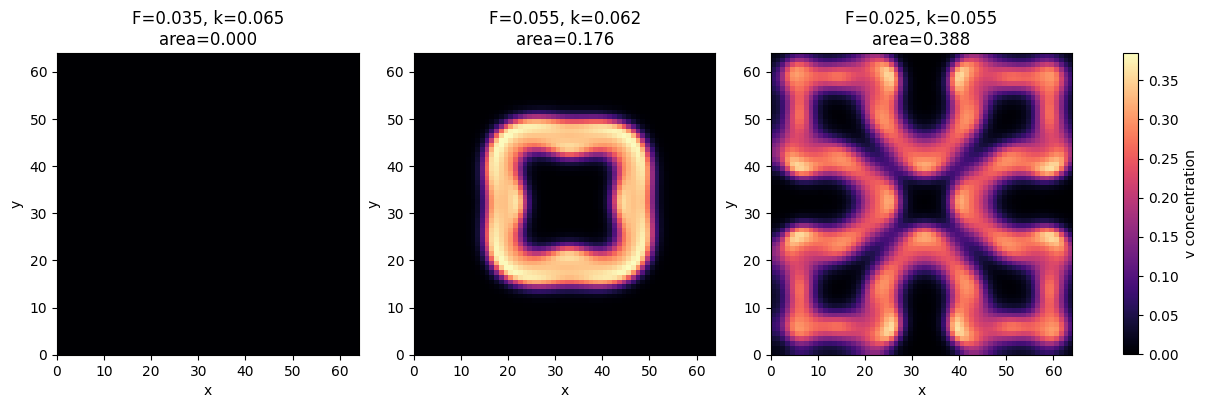

,F,k,seed,area_fraction
0,0.035,0.065,0,0.000000
1,0.055,0.062,0,0.176025
2,0.025,0.055,0,0.388184


In [2]:
# 動作確認用の探索設定．研究では終了時刻・格子への感度も確認する．
SCAN = dict(N=64, length=64.0, t_end=1500.0, dt=1.0, Du=0.16, Dv=0.08)
THRESHOLD = 0.2


def scan_gray_scott(params, seed):
    results = []
    for F, k in params:
        result = gray_scott(**SCAN, F=F, k=k, seed=seed)
        results.append(dict(F=F, k=k, seed=seed, v=result['v'],
                            area_fraction=np.mean(result['v'] >= THRESHOLD),
                            diagnostics=result['diagnostics']))
    return results


def plot_gray_scott_scan(results):
    if not results:
        raise ValueError('results must contain at least one condition')
    fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 4), constrained_layout=True)
    axes = np.atleast_1d(axes)
    vmax = max(max(r['v'].max() for r in results), 1e-12)
    for ax, result in zip(axes, results):
        im = ax.imshow(result['v'], origin='lower', cmap='magma', vmin=0, vmax=vmax,
                       extent=[0, SCAN['length'], 0, SCAN['length']])
        ax.set(title=f"F={result['F']}, k={result['k']}\narea={result['area_fraction']:.3f}",
               xlabel='x', ylabel='y')
    fig.colorbar(im, ax=axes.tolist(), label='v concentration', shrink=0.8)
    plt.show()


results = scan_gray_scott([(0.035, 0.065), (0.055, 0.062), (0.025, 0.055)], seed=0)
plot_gray_scott_scan(results)
display(pd.DataFrame([{key: r[key] for key in ['F', 'k', 'seed', 'area_fraction']} for r in results]))

## 解答例：拡散比と濃度の不均一さ

`Dv` だけを変える．刻みの条件に違反する値を指定すると停止するので，その場合は全比較条件の `dt` を見直す．分散を模様の細かさと同一視せず，細かさの指標は22章の検証後に追加する．

In [3]:
def diffusion_ratio_sweep(Dv_values):
    rows = []
    for value in Dv_values:
        settings = dict(SCAN, Dv=value)
        result = gray_scott(**settings, F=0.035, k=0.065, seed=0)
        field = result['v']
        rows.append(dict(Dv=value, ratio=value/SCAN['Du'], mean=field.mean(),
                         variance=field.var(), area_fraction=np.mean(field >= THRESHOLD)))
    return pd.DataFrame(rows)


display(diffusion_ratio_sweep([0.04, 0.08, 0.12]))

,Dv,ratio,mean,variance,area_fraction
0,0.04,0.25,1.717460e-01,2.187767e-02,0.359863
1,0.08,0.50,4.624778e-66,7.771689e-132,0.000000
2,0.12,0.75,6.413841e-68,4.021096e-136,0.000000


## 解答例：時間刻みの検証

In [4]:
def time_convergence(dts):
    rows = []
    for dt in dts:
        result = gray_scott(N=8, length=8, t_end=20, dt=dt,
                            initial=(np.full((8, 8), 0.7), np.zeros((8, 8))))
        exact = 1 - 0.3*np.exp(-0.035*20)
        rows.append(dict(dt=result['dt'], error=np.max(np.abs(result['u']-exact))))
    table = pd.DataFrame(rows)
    table['previous/current error'] = table['error'].shift()/table['error']
    return table


display(time_convergence([1.0, 0.5, 0.25]))

,dt,error,previous/current error
0,1.00,0.001857,NaN
1,0.50,0.000920,2.017597
2,0.25,0.000458,2.008700


## 解答例：考察

面積比は閾値以上の領域の割合であり，配置を区別しない．分散は濃度差の大きさであり，波長を区別しない．たとえば同じ振幅で波長だけが違う余弦波は同じ分散を持つ．生成図の差を表の数値だけですべて説明しようとせず，何を測っていないかも述べる．

時間刻みの表では誤差比が約2へ近づく．これは一様場の時間積分の検証であり，長時間の模様計算の精度をすべて保証するものではない．研究では領域と終了時刻を固定した空間刻みの検証，別seed，別時刻の結果も加える．